Dashboard EDA
Stwórz kompletny dashboard EDA dla datasetu Penguins z 4 wykresami:
Rozkład masy ciała (histogram z KDE)
Scatter: bill_length vs bill_depth z kolorowaniem według gatunku
Box plot: flipper_length według gatunku
Bar plot: liczebność według gatunku i płci

Dataset: penguins = sns.load_dataset('penguins')

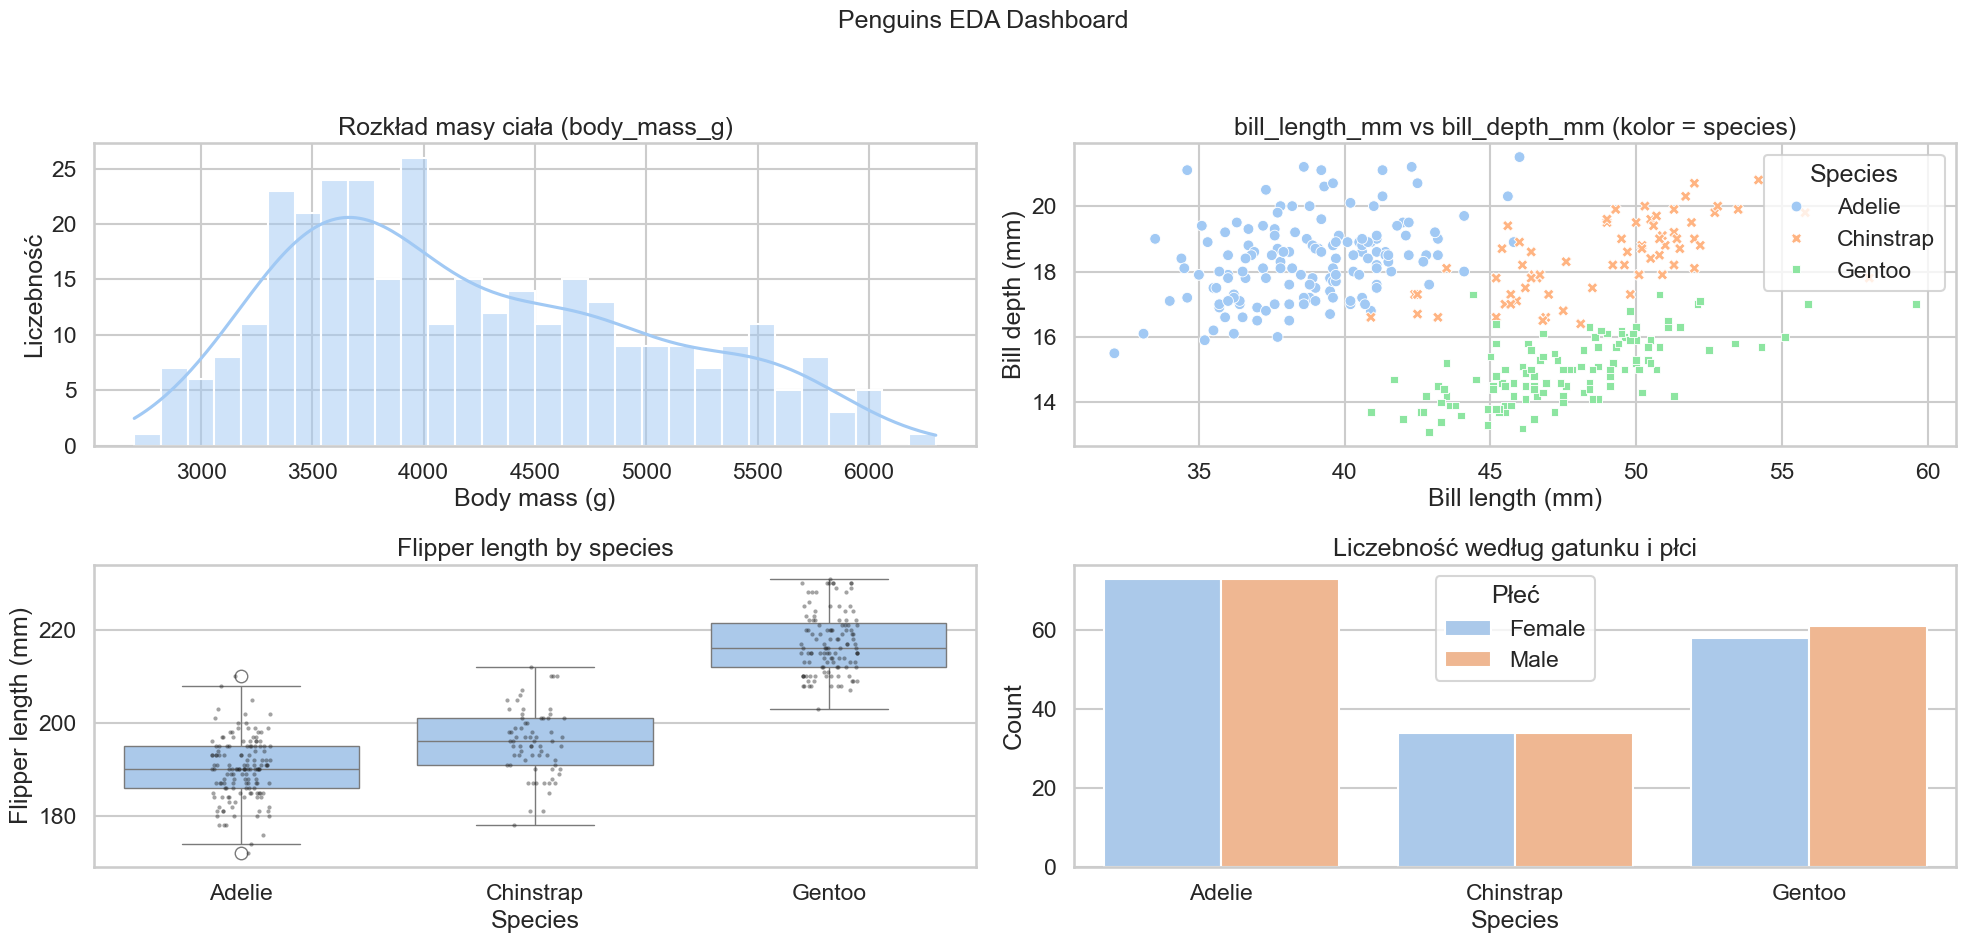

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Wczytanie danych
penguins = sns.load_dataset('penguins')

# dropna()
cols_needed = ['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'species', 'sex']
df = penguins[cols_needed].copy().dropna()

# Układ: 2x2
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# 1) Histogram body mass z KDE
ax = axes[0, 0]
sns.histplot(df['body_mass_g'], kde=True, bins=30, element='bars', ax=ax, color='C0')
ax.set_title('Rozkład masy ciała (body_mass_g)')
ax.set_xlabel('Body mass (g)')
ax.set_ylabel('Liczebność')

# 2) Scatter: bill_length vs bill_depth, kolor według species
ax = axes[0, 1]
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species', style='species', s=60, ax=ax)
ax.set_title('bill_length_mm vs bill_depth_mm (kolor = species)')
ax.set_xlabel('Bill length (mm)')
ax.set_ylabel('Bill depth (mm)')
ax.legend(title='Species', loc='best')

# 3) Boxplot: flipper_length według species
ax = axes[1, 0]
sns.boxplot(data=df, x='species', y='flipper_length_mm', ax=ax)
sns.stripplot(data=df, x='species', y='flipper_length_mm', color='k', size=3, alpha=0.4, jitter=True, ax=ax)
ax.set_title('Flipper length by species')
ax.set_xlabel('Species')
ax.set_ylabel('Flipper length (mm)')

# 4) Bar plot: liczebność według species i sex (stacked-like side-by-side)
ax = axes[1, 1]
count_df = df.groupby(['species', 'sex']).size().reset_index(name='count')
sns.barplot(data=count_df, x='species', y='count', hue='sex', ax=ax)
ax.set_title('Liczebność według gatunku i płci')
ax.set_xlabel('Species')
ax.set_ylabel('Count')
ax.legend(title='Płeć')

plt.suptitle('Penguins EDA Dashboard', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Wykres czasowy
Utwórz wykres ceny akcji w czasie z:
Główną linią ceny
Średnią kroczącą 7-dniową (MA7)
Średnią kroczącą 21-dniową (MA21)
Zacienionym obszarem między MA7 a MA21

Dane:
    import numpy as np
    import pandas as pd
    np.random.seed(42)
    dates = pd.date_range('2025-01-01', periods=100)
    price = 100 + np.cumsum(np.random.randn(100))
    df = pd.DataFrame({'date': dates, 'price': price})

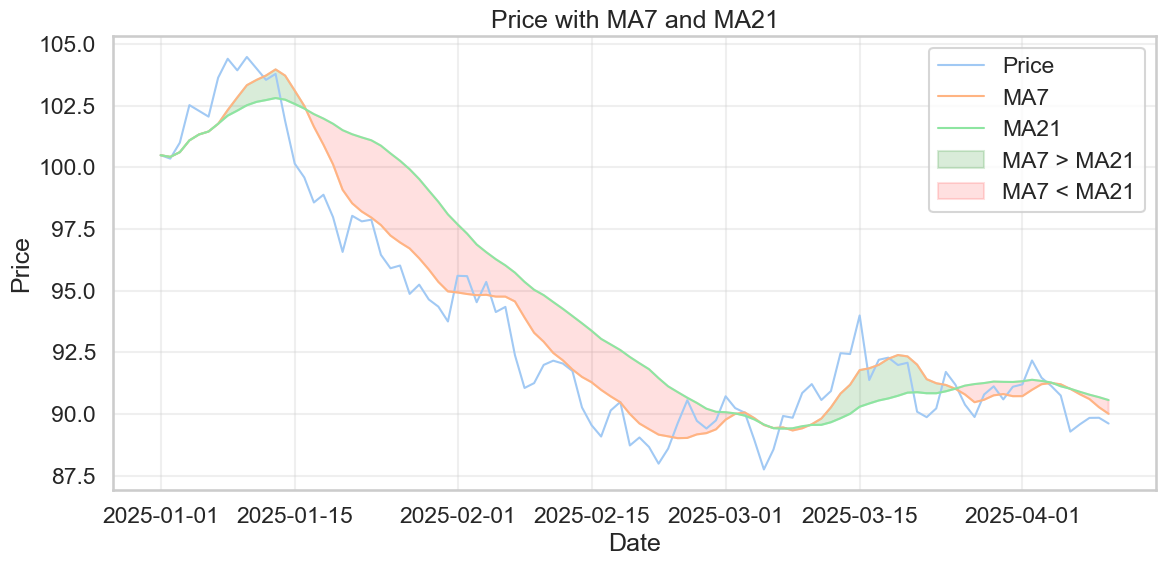

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
dates = pd.date_range('2025-01-01', periods=100)
price = 100 + np.cumsum(np.random.randn(100))
df = pd.DataFrame({'date': dates, 'price': price})

# Obliczenia: MA7 i MA21
df = df.set_index('date')
df['MA7'] = df['price'].rolling(window=7, min_periods=1).mean()
df['MA21'] = df['price'].rolling(window=21, min_periods=1).mean()

# Wykres
plt.figure(figsize=(12,6))
plt.plot(df.index, df['price'], label='Price', color='C0', linewidth=1.5)
plt.plot(df.index, df['MA7'], label='MA7', color='C1', linewidth=1.5)
plt.plot(df.index, df['MA21'], label='MA21', color='C2', linewidth=1.5)

plt.fill_between(df.index, df['MA7'], df['MA21'], where=(df['MA7']>=df['MA21']),
                 interpolate=True, color='green', alpha=0.15, label='MA7 > MA21')

plt.fill_between(df.index, df['MA7'], df['MA21'], where=(df['MA7']<df['MA21']),
                 interpolate=True, color='red', alpha=0.12, label='MA7 < MA21')

plt.title('Price with MA7 and MA21')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
